In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../Raw/Market capitalization of listed domestic companies/API_CM.MKT.LCAP.CD_DS2_en_csv_v2_999.csv", skiprows=4)
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6.198511e+10,7.182296e+10,6.471762e+10,6.884437e+10,NaN,NaN,NaN,NaN
4,Angola,AGO,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.230977e+12,8.653276e+11,1.056341e+12,1.051529e+12,1.143003e+12,1.171748e+12,1.025827e+12,9.856974e+11,NaN,NaN
264,Zambia,ZMB,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.716490e+09,4.034770e+09,4.037230e+09,3.456230e+09,7.765130e+09,NaN,NaN


In [4]:
yr_cols = [col for col in df.columns if col.startswith('20') or col.startswith('19')]
df[yr_cols] = df[yr_cols].apply(pd.to_numeric, errors='coerce')

In [5]:
# Melt the DataFrame to long format
# 'Country Name', 'Country Code', 'Indicator Name', 'Indicator Code' are id_vars
id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
df_long = df.melt(id_vars=id_vars, value_vars=yr_cols, var_name='Year', value_name='Market Cap')

df_long["Year"] = df_long["Year"].astype(int)
df_long

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Market Cap
0,Aruba,ABW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
1,Africa Eastern and Southern,AFE,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
2,Afghanistan,AFG,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
3,Africa Western and Central,AFW,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
4,Angola,AGO,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,1960,NaN
...,...,...,...,...,...,...
17551,Kosovo,XKX,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17552,"Yemen, Rep.",YEM,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17553,South Africa,ZAF,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN
17554,Zambia,ZMB,Market capitalization of listed domestic compa...,CM.MKT.LCAP.CD,2025,NaN


In [6]:
df_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    17556 non-null  object 
 1   Country Code    17556 non-null  object 
 2   Indicator Name  17556 non-null  object 
 3   Indicator Code  17556 non-null  object 
 4   Year            17556 non-null  int64  
 5   Market Cap      3697 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 823.1+ KB


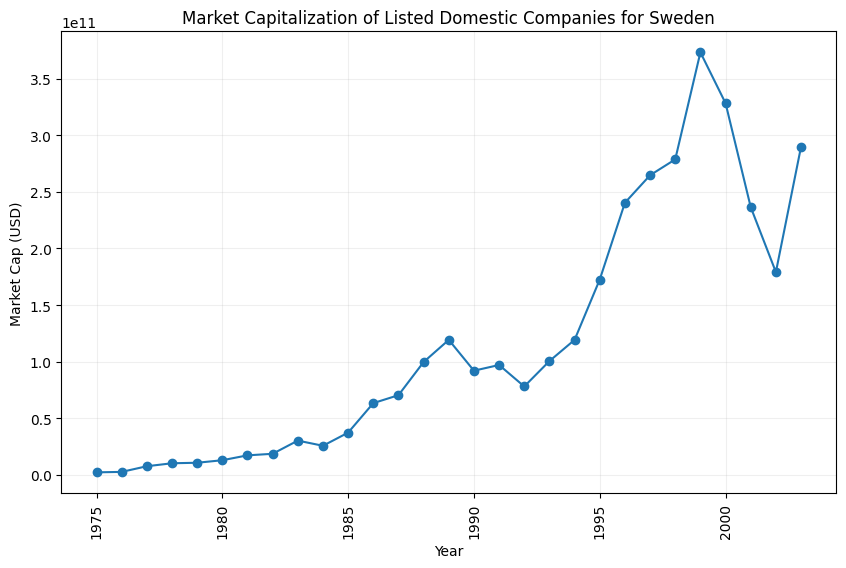

,Year,Market Cap
count,66.000000,2.900000e+01
mean,1992.500000,1.164924e+11
std,19.196354,1.112342e+11
min,1960.000000,2.200010e+09
25%,1976.250000,1.859675e+10
50%,1992.500000,9.201474e+10
75%,2008.750000,1.791174e+11
max,2025.000000,3.732776e+11


In [7]:
# Inspect a country
country = "Sweden"
nor = df_long[df_long['Country Name'] == country].sort_values('Year')
plt.figure(figsize=(10, 6))
plt.plot(nor['Year'], nor['Market Cap'], marker='o')
plt.title(f'Market Capitalization of Listed Domestic Companies for {country}')
plt.xlabel('Year')
plt.ylabel('Market Cap (USD)')
plt.xticks(rotation=90)
plt.grid(alpha=0.2)
# plt.yscale("log")
plt.show()

nor.describe()

In [8]:
# Add iso3 code as the country code
df_long["iso3"] = df_long["Country Code"]

In [9]:
df_long[df_long["iso3"]=="SWE"].groupby("iso3")["Market Cap"].mean()

iso3
SWE    1.164924e+11
Name: Market Cap, dtype: float64

In [10]:
# Export to clean csv
df_long.to_csv("../Clean/market_cap.csv", index=False)

/var/folders/_x/74827dzs033cwdj2j4gch59r0000gn/T/ipykernel_13805/1914864863.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf["Year"] = tf["Year"].astype(int)


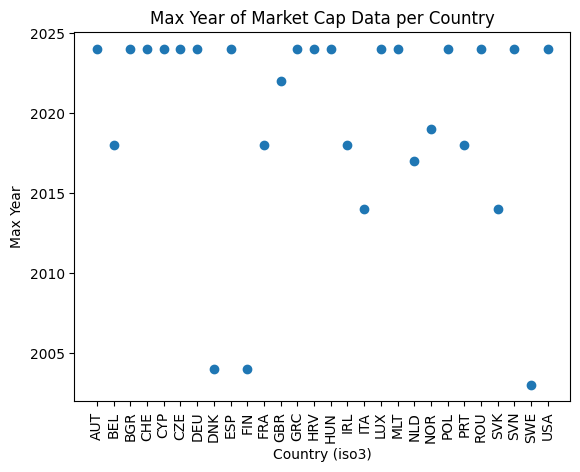

In [11]:
# Give me max year per country
# Fix df_full to only be countries that we have defined it to be
# ── Country set: EU-27 + 4 outside options ────────────────────────────────
EU27 = [
    'AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC',
    'HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK',
    'SVN','ESP','SWE'
]
OUTSIDE = ['USA','GBR','CHE','NOR']
COUNTRIES = EU27 + OUTSIDE          # n = 31

tf = df_long[df_long["iso3"].isin(COUNTRIES)]
tf["Year"] = tf["Year"].astype(int)
tf = tf.dropna(subset=["Market Cap"])
max_yr = tf.groupby("iso3")["Year"].max().reset_index()

plt.figure()
plt.scatter(max_yr["iso3"], max_yr["Year"])
plt.xticks(rotation=90)
plt.title("Max Year of Market Cap Data per Country")
plt.xlabel("Country (iso3)")
plt.ylabel("Max Year")
plt.show()

In [12]:
# Get market cap as a ratio of GDP from PWT
pwt = pd.read_csv("../Clean/pwt.csv")
pwt["Real GDP"] = pwt["Real GDP"] * 1e3
pwt["Capital Stock"] = pwt["Capital Stock"] * 1e3
pwt

,Real GDP,Capital Stock,Worker Population,Total Population,Labour Share,Depreciation Rate,TFP,Interest Rate,Investment Share,Human Capital,countrycode,year
0,3.682509e+05,7.769615e+05,NaN,0.058950,NaN,0.040318,NaN,NaN,0.431354,NaN,ABW,1970
1,4.017193e+05,8.571512e+05,NaN,0.058781,NaN,0.039650,NaN,NaN,0.418163,NaN,ABW,1971
2,4.382295e+05,9.445862e+05,NaN,0.058895,NaN,0.039095,NaN,NaN,0.419161,NaN,ABW,1972
3,4.780579e+05,1.039993e+06,NaN,0.059435,NaN,0.038641,NaN,NaN,0.403070,NaN,ABW,1973
4,5.215061e+05,1.144000e+06,NaN,0.060122,NaN,0.038273,NaN,NaN,0.390737,NaN,ABW,1974
...,...,...,...,...,...,...,...,...,...,...,...,...
11196,4.444503e+07,1.076821e+08,5.272343,15.271368,0.533381,0.059923,1.057740,0.275977,0.130147,2.713408,ZWE,2019
11197,4.097079e+07,1.092483e+08,5.206007,15.526888,0.533381,0.060208,0.973187,0.263760,0.119450,2.746586,ZWE,2020
11198,4.444020e+07,1.109798e+08,5.298346,15.797210,0.533381,0.060136,1.000000,0.205160,0.153113,2.770661,ZWE,2021
11199,4.714755e+07,1.141349e+08,5.344455,16.069056,0.533381,0.059788,0.997026,0.263871,0.172489,2.795292,ZWE,2022


In [13]:
tf = pd.merge(df_long[["iso3", "Year", "Market Cap"]]
              , pwt[["countrycode", "year", "Real GDP", "Capital Stock"]]
              , left_on=["iso3", "Year"]
              , right_on=["countrycode", "year"]
              , how="inner")
tf

,iso3,Year,Market Cap,countrycode,year,Real GDP,Capital Stock
0,ARG,1960,NaN,ARG,1960,3.270193e+08,8.167028e+08
1,AUS,1960,NaN,AUS,1960,2.161410e+08,1.100372e+09
2,AUT,1960,NaN,AUT,1960,1.156752e+08,4.246837e+08
3,BDI,1960,NaN,BDI,1960,2.446836e+06,7.228822e+06
4,BEL,1960,NaN,BEL,1960,1.378493e+08,7.022839e+08
...,...,...,...,...,...,...,...
10359,VNM,2023,1.878183e+11,VNM,2023,1.383722e+09,4.829024e+09
10360,YEM,2023,NaN,YEM,2023,3.511488e+07,5.723072e+08
10361,ZAF,2023,1.025827e+12,ZAF,2023,8.000849e+08,3.022919e+09
10362,ZMB,2023,3.456230e+09,ZMB,2023,6.859687e+07,2.791885e+08


In [14]:
# Get the proportion of M by Real GDP and by Capital Stock
tf["Market Cap / Real GDP"] = tf["Market Cap"] / tf["Real GDP"]
tf["Market Cap / Capital Stock"] = tf["Market Cap"] / tf["Capital Stock"]
tf[["Market Cap / Real GDP", "Market Cap / Capital Stock"]].describe()

,Market Cap / Real GDP,Market Cap / Capital Stock
count,2613.000000,2613.000000
mean,355.221644,80.920251
std,811.312902,152.618528
min,0.050817,0.015542
25%,55.056760,14.544467
50%,157.664506,36.962262
75%,385.471702,94.540830
max,14829.972282,2485.897324


In [15]:
tf[["Market Cap", "Capital Stock", "Real GDP"]].apply(np.log).corr()

,Market Cap,Capital Stock,Real GDP
Market Cap,1.000000,0.798267,0.790486
Capital Stock,0.798267,1.000000,0.961396
Real GDP,0.790486,0.961396,1.000000


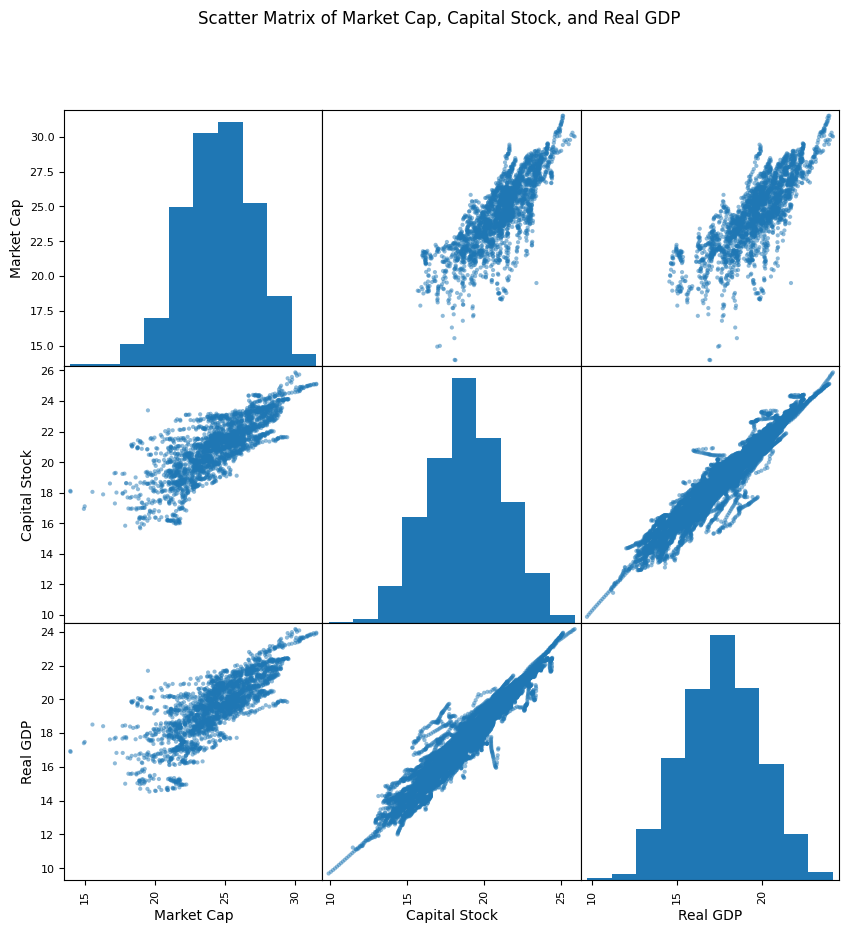

In [16]:
from pandas.plotting import scatter_matrix

scatter_matrix(tf[["Market Cap", "Capital Stock", "Real GDP"]].apply(np.log), figsize=(10, 10))
plt.suptitle("Scatter Matrix of Market Cap, Capital Stock, and Real GDP")
plt.show()

In [17]:
# OLS, smf
import statsmodels.formula.api as smf

# Log-log regression
model = smf.ols("np.log(Q('Market Cap')) ~  np.log(Q('Capital Stock')) + C(iso3) + C(Year)", data=tf).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     np.log(Q('Market Cap'))   R-squared:                       0.946
Model:                                 OLS   Adj. R-squared:                  0.943
Method:                      Least Squares   F-statistic:                     289.0
Date:                     Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                             13:32:27   Log-Likelihood:                -2372.6
No. Observations:                     2613   AIC:                             5045.
Df Residuals:                         2463   BIC:                             5926.
Df Model:                              149                                         
Covariance Type:                 nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [21]:
# Make a new dataframe that uses the model 
# to fill in the gaps of the market cap data.

df2 = tf.copy()
df2["Market Cap Predicted"] = np.exp(model.predict(df2))
df2[["Market Cap", "Market Cap Predicted"]].describe()

,Market Cap,Market Cap Predicted
count,2.613000e+03,1.019100e+04
mean,6.277762e+11,1.842567e+11
std,2.749193e+12,1.485047e+12
min,1.152430e+06,1.940136e+04
25%,7.845150e+09,1.988165e+08
50%,4.632809e+10,1.785919e+09
75%,2.649744e+11,1.553420e+10
max,4.897940e+13,4.040395e+13


In [22]:
df2

,iso3,Year,Market Cap,countrycode,year,Real GDP,Capital Stock,Market Cap / Real GDP,Market Cap / Capital Stock,Market Cap Predicted
0,ARG,1960,NaN,ARG,1960,3.270193e+08,8.167028e+08,NaN,NaN,3.663994e+09
1,AUS,1960,NaN,AUS,1960,2.161410e+08,1.100372e+09,NaN,NaN,6.723582e+10
2,AUT,1960,NaN,AUT,1960,1.156752e+08,4.246837e+08,NaN,NaN,4.583960e+09
3,BDI,1960,NaN,BDI,1960,2.446836e+06,7.228822e+06,NaN,NaN,5.505978e+07
4,BEL,1960,NaN,BEL,1960,1.378493e+08,7.022839e+08,NaN,NaN,2.647569e+10
...,...,...,...,...,...,...,...,...,...,...
10359,VNM,2023,1.878183e+11,VNM,2023,1.383722e+09,4.829024e+09,135.734114,38.893636,1.586096e+11
10360,YEM,2023,NaN,YEM,2023,3.511488e+07,5.723072e+08,NaN,NaN,1.982647e+10
10361,ZAF,2023,1.025827e+12,ZAF,2023,8.000849e+08,3.022919e+09,1282.147822,339.349812,1.182567e+12
10362,ZMB,2023,3.456230e+09,ZMB,2023,6.859687e+07,2.791885e+08,50.384662,12.379559,3.203899e+09


In [23]:
# Save it as a new csv
df2.to_csv("../Clean/market_cap_with_predictions.csv", index=False)